In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("Data/train.csv")
test_df = pd.read_csv("Data/test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (428, 3)
Test Shape: (106, 3)


,Id,Article,Category
0,1976,lifestyle governs mobile choice faster better ...,tech
1,1797,french honour director parker british film dir...,entertainment
2,1866,fockers fuel festive film chart comedy meet fo...,entertainment
3,1153,housewives lift channel 4 ratings debut us tel...,entertainment
4,342,u2 desire number one u2 three prestigious gram...,entertainment


# Task 1 - Exploratory Data Analysis

## Task 1(a) - Dataset Loading and Feature Extraction

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

# Convert article text into feature vectors
X_train = vectorizer.fit_transform(train_df["Article"])
X_test = vectorizer.transform(test_df["Article"])

# Labels
y_train = train_df["Category"]
y_test = test_df["Category"]

# Print dataset information
print("Training Dataset Shape:", X_train.shape)
print("Testing Dataset Shape:", X_test.shape)

print("\nNumber of training articles:", X_train.shape[0])
print("Number of testing articles:", X_test.shape[0])

print("\nNumber of extracted features:", X_train.shape[1])

Training Dataset Shape: (428, 5000)
Testing Dataset Shape: (106, 5000)

Number of training articles: 428
Number of testing articles: 106

Number of extracted features: 5000


In [20]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Convert sparse matrix to dataframe
train_features_df = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names
)

# Show first 5 articles
example_df = pd.DataFrame({
    "Article": train_df["Article"].head(5),
    "Category": train_df["Category"].head(5)
})

display(example_df)

# Display first few extracted features
train_features_df.head()

,Article,Category
0,lifestyle governs mobile choice faster better ...,tech
1,french honour director parker british film dir...,entertainment
2,fockers fuel festive film chart comedy meet fo...,entertainment
3,housewives lift channel 4 ratings debut us tel...,entertainment
4,u2 desire number one u2 three prestigious gram...,entertainment


,000,007,05,06,10,100,100m,101,10th,11,...,youngsters,zach,zafi,zellweger,zeppelin,zero,zhang,zombies,zone,zoom
0,0.021014,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.053595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.060924,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.025853,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Task 1(b) - Term Frequency Analysis

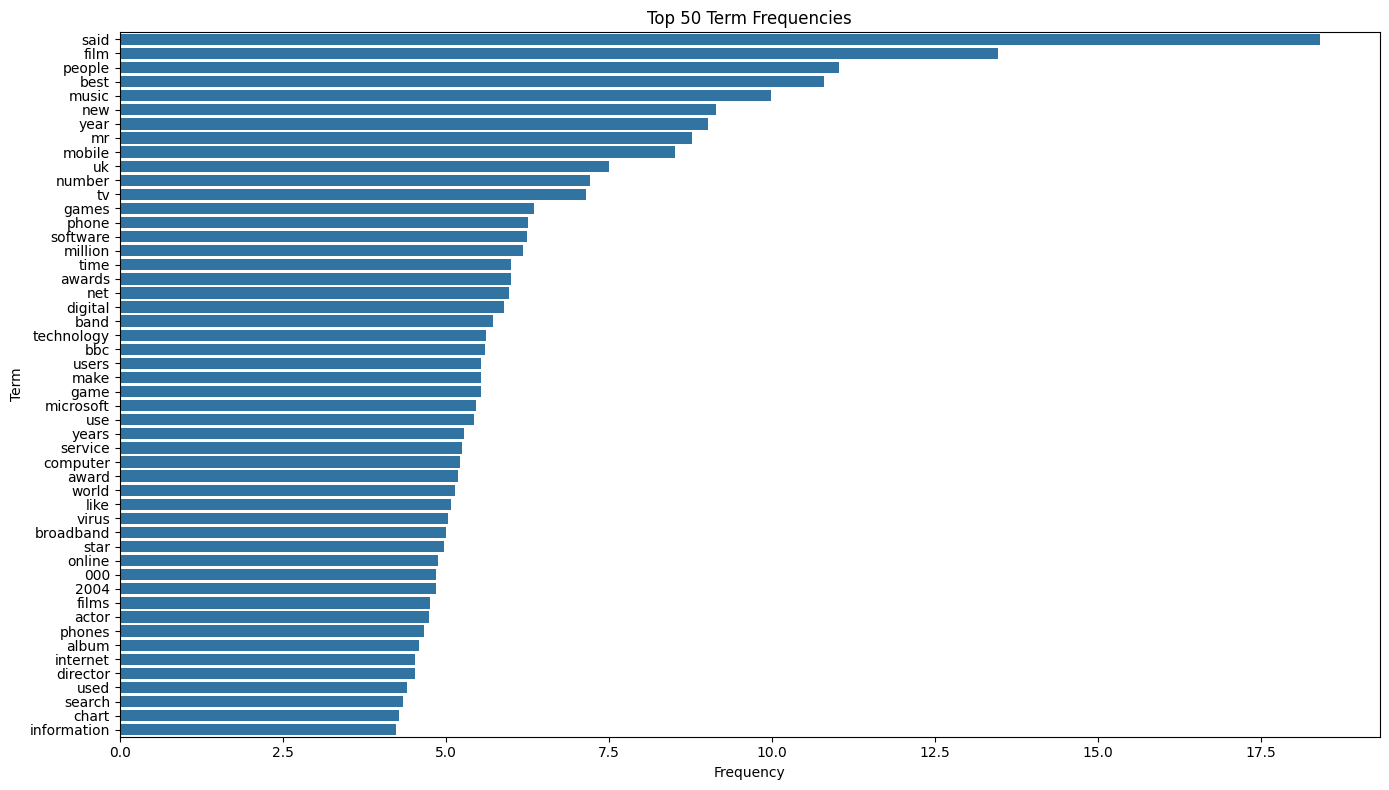

In [21]:
# Plot 1: Top 50 terms used

# Sum TF-IDF scores across all documents
term_frequencies = np.array(X_train.sum(axis=0)).flatten()

# Create dataframe
tf_df = pd.DataFrame({
    "Term": feature_names,
    "Frequency": term_frequencies
})

# Sort descending
tf_df = tf_df.sort_values(by="Frequency", ascending=False)

# Top 50 terms
top_50 = tf_df.head(50)

# Plot
plt.figure(figsize=(14,8))
sns.barplot(data=top_50, x="Frequency", y="Term")

plt.title("Top 50 Term Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

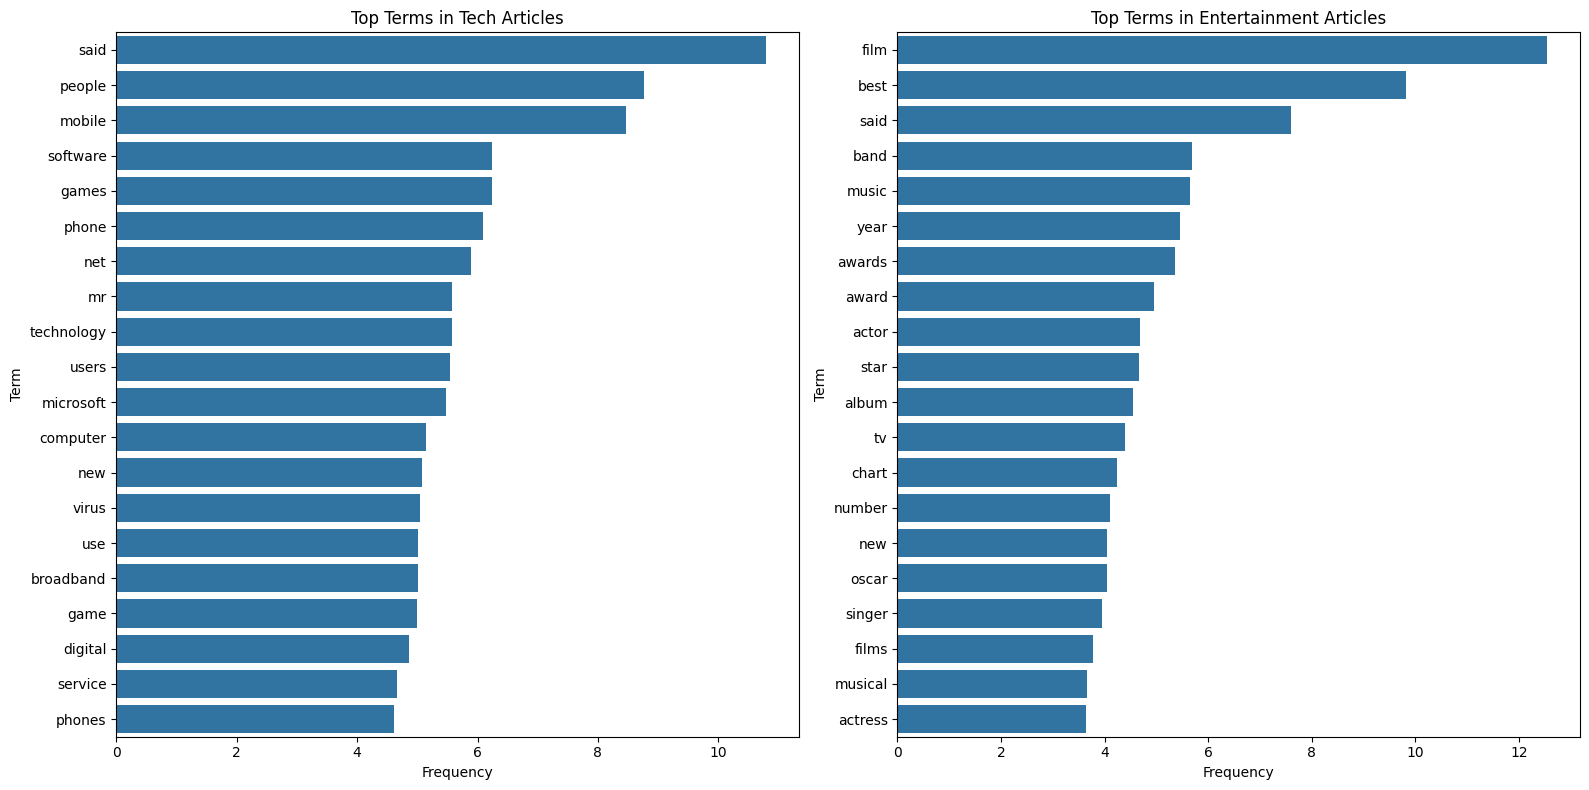

In [22]:
# Plot 2: Top terms in entertainment and tech articles

# Separate classes
tech_articles = train_df[train_df["Category"] == "tech"]
ent_articles = train_df[train_df["Category"] == "entertainment"]

# Vectorize separately
tech_matrix = vectorizer.transform(tech_articles["Article"])
ent_matrix = vectorizer.transform(ent_articles["Article"])

# Sum frequencies
tech_freq = np.array(tech_matrix.sum(axis=0)).flatten()
ent_freq = np.array(ent_matrix.sum(axis=0)).flatten()

# Create dataframes
tech_df = pd.DataFrame({
    "Term": feature_names,
    "Frequency": tech_freq
}).sort_values(by="Frequency", ascending=False).head(20)

ent_df = pd.DataFrame({
    "Term": feature_names,
    "Frequency": ent_freq
}).sort_values(by="Frequency", ascending=False).head(20)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16,8))

sns.barplot(
    data=tech_df,
    x="Frequency",
    y="Term",
    ax=axes[0]
)

axes[0].set_title("Top Terms in Tech Articles")

sns.barplot(
    data=ent_df,
    x="Frequency",
    y="Term",
    ax=axes[1]
)

axes[1].set_title("Top Terms in Entertainment Articles")

plt.tight_layout()
plt.show()

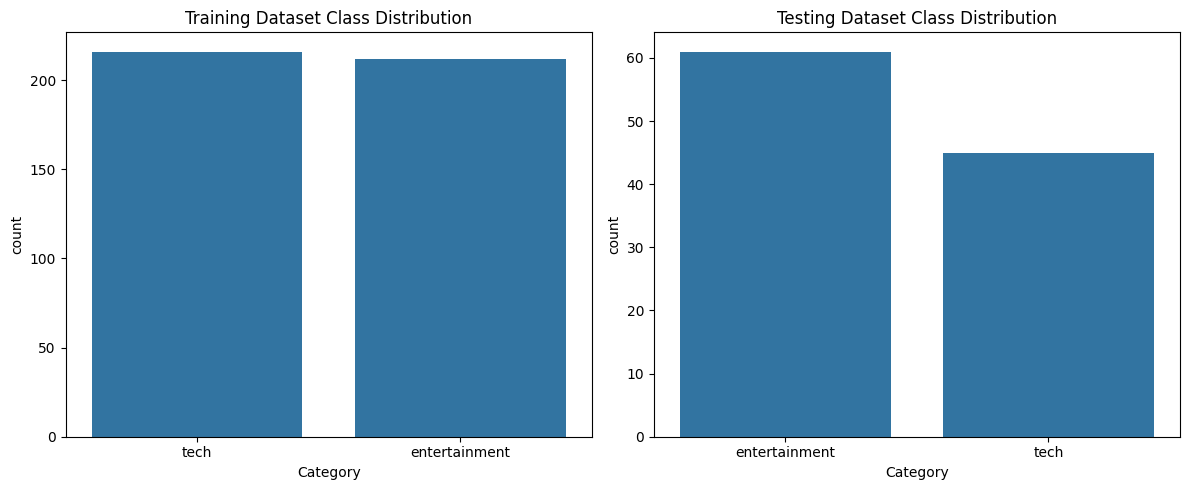

In [23]:
# Plot 3: class distributions
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    data=train_df,
    x="Category",
    ax=axes[0]
)

axes[0].set_title("Training Dataset Class Distribution")

sns.countplot(
    data=test_df,
    x="Category",
    ax=axes[1]
)

axes[1].set_title("Testing Dataset Class Distribution")

plt.tight_layout()
plt.show()

### Discussion

TF-IDF vectorization was used to transform the news articles into numerical feature vectors suitable for machine learning classification. The vectorizer extracted 5000 textual features from the training dataset.

The term frequency analysis shows noticeable differences between the vocabularies used in tech and entertainment articles. Technology articles frequently contain terms associated with software, mobile devices, games, and digital technology, while entertainment articles contain words related to films, actors, music, television, and awards.

The class distribution plots show that the training dataset is relatively balanced between the two categories, which is beneficial for training classification models. The testing dataset shows a slight imbalance but still contains substantial representation from both classes.